In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv(r"c:\Users\Ollie\Uni Stuff\Summer Coding\Datasets\Diabetes Dataset\diabetes_data.zip")

In [17]:
print("--- Dataset Information ---")
print(df.info())


print("--- Dataset Shape ---")
print(df.shape)


print("--- Dataset Head ---")
print(df.head())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
--- Dataset Shape ---
(768, 9)
--- Dataset Head ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1          

In [18]:
positive_diabetes = df[df["Outcome"] == 1]

negative_diabetes = df[df["Outcome"] == 0]

print(positive_diabetes.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
2            8      183             64              0        0  23.3   
4            0      137             40             35      168  43.1   
6            3       78             50             32       88  31.0   
8            2      197             70             45      543  30.5   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
2                     0.672   32        1  
4                     2.288   33        1  
6                     0.248   26        1  
8                     0.158   53        1  


In [19]:
average_glucose=df["Glucose"].mean()

exceed_glucose=df[df["Glucose"]>average_glucose]

diabetes_number_exceed  = exceed_glucose["Outcome"].value_counts()

In [20]:
melted_exceed = pd.melt(
    frame=exceed_glucose,
    id_vars=["Pregnancies", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"],
    value_vars=["Outcome"],
    var_name="Demographic",
    value_name="Status"
)

In [21]:
sorted_melted_exceed= melted_exceed.sort_values(by="Age", ascending=True)

These 2 graphs show a very large number of values at 0 for skin thickness and insulin. This shows that a large number of values are left as zero when they likely shouldn't, showing that there isn't just a large cohort of those with
insulin levels of 0. Many have skin thickness of 0s and insulins of 0, so this likely isn't just type 1 diabetes and is instead blank values. I could also remove only those that are non-diabetic, however, according to the
Wikipedia for the population the study was conducted on, the study is largely type 2 diabetes, so would the trial would screen out those with biologically 0 insulin. So we can see it as blank values.

The last graph shows those with missing skin thickness and there skin thickness plotted against insulin. This leads to a graph that has a single lone point at 0, which shows that whenever there was skin thickness at 0, insulin was also at 0.
We also know by the last lines in the section that there are 227 patients with 0 as their skin thickness, and that all of those have 0 insulin. Therefore, the missingness is almost entirely uniform, although 392 patients have missing values. 

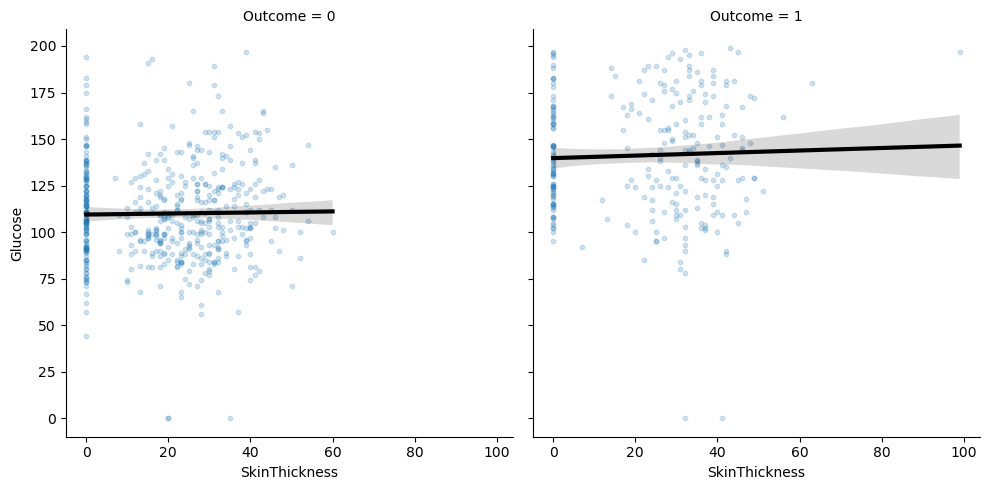

In [22]:
sns.lmplot(data=df, x="SkinThickness", y="Glucose", col="Outcome", scatter_kws={'alpha':0.2, "s":10}, line_kws={"linewidth":3, "color":"black"})

plt.show()
plt.close()

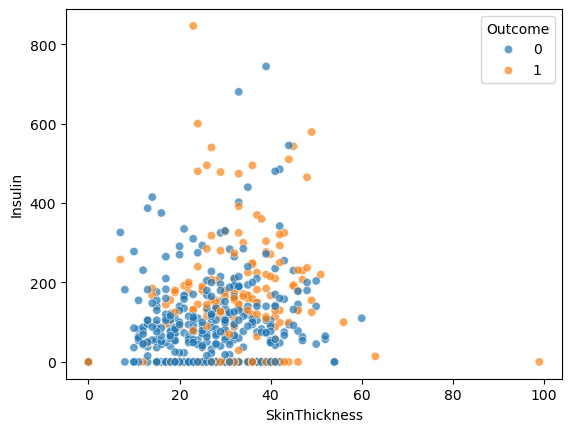

In [23]:
sns.scatterplot(data=df, x="SkinThickness", y="Insulin", hue="Outcome", alpha=0.7)

plt.show()
plt.close()

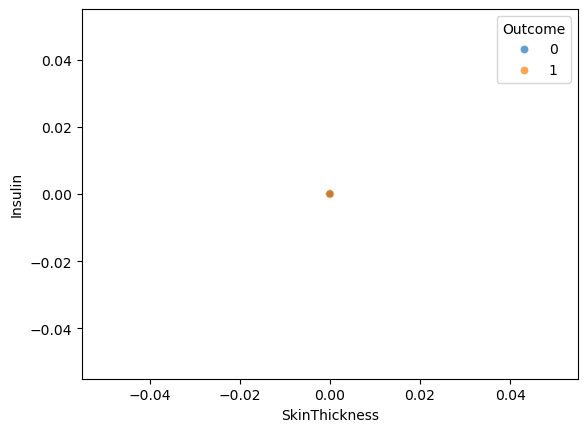

In [24]:
skin_null = df[df["SkinThickness"]==0]

sns.scatterplot(data=skin_null, x="SkinThickness", y="Insulin", hue="Outcome", alpha=0.7)

plt.show()
plt.show()

In [25]:
print(skin_null.value_counts())

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
0            57       60             0              0        21.7  0.735                     67   0          1
7            133      84             0              0        40.2  0.696                     37   0          1
6            92       92             0              0        19.9  0.188                     28   0          1
             96       0              0              0        23.7  0.190                     28   0          1
             102      82             0              0        30.8  0.180                     36   1          1
                                                                                                            ..
3            121      52             0              0        36.0  0.127                     25   1          1
             122      78             0              0        23.0  0.254                     40   0          1
      

In [26]:
print(skin_null[skin_null["Insulin"]==0].value_counts())

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
0            57       60             0              0        21.7  0.735                     67   0          1
7            133      84             0              0        40.2  0.696                     37   0          1
6            92       92             0              0        19.9  0.188                     28   0          1
             96       0              0              0        23.7  0.190                     28   0          1
             102      82             0              0        30.8  0.180                     36   1          1
                                                                                                            ..
3            121      52             0              0        36.0  0.127                     25   1          1
             122      78             0              0        23.0  0.254                     40   0          1
      

This looks through the columns we want no 0s in, and then replaces with a null value. Then, it prints the count of those rows that have null values in each column. 

In [27]:
replace_value = ["Age", "SkinThickness", "Insulin", "BMI", "BloodPressure", "Glucose", "DiabetesPedigreeFunction"]

df[replace_value] = df[replace_value].replace(0,np.nan)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In order to train a model on the data, the null values must be replaced with a suitable placeholder. This allows the model to be trained appropriately. From what I can tell online, using imputation to replace the nulls with the median
seems to be the best approach. However, we must investigate the distribution of the null values first, splitting the dataset into a healthy cohort and then summing the nulls again. We then find the proportions of nulls, and compare
with the initial dataset. This is largely to test the hypothesis as to whether those taking the measurements were doing so as the patient tested positive or negative, and so the measurements weren't taken due to that. Similar to the 
reasoning laid out in one of the previous summaries.

In [28]:
print((df.isnull().sum()/len(df)*100).round(1))

Pregnancies                  0.0
Glucose                      0.7
BloodPressure                4.6
SkinThickness               29.6
Insulin                     48.7
BMI                          1.4
DiabetesPedigreeFunction     0.0
Age                          0.0
Outcome                      0.0
dtype: float64


In [29]:
healthy_df = df[df["Outcome"] == 0]

print(((healthy_df[replace_value].isnull().sum()/ len(healthy_df))*100).round(1))

Age                          0.0
SkinThickness               27.8
Insulin                     47.2
BMI                          1.8
BloodPressure                3.8
Glucose                      0.6
DiabetesPedigreeFunction     0.0
dtype: float64


This shows the distribution of the nulls, with the values being incredibly close together for both the initial and healthy dataset (48.7% vs 47.2% for Insulin). This suggests that whether or not the patient had tested positive had no bearing on the presence of null values. This shows how using a global median would lead to an incredible large flattening of the data, as the nulls are evenly spread between outcomes. This would lead to a flattening of outliers.
Taking into account also the way in which the skin thickness and insulin measurements are also intertwined, this would also create a large segment of the data where both the skin thickness and insulin levels are the same respectively, distorting the data considerably around these values. This distortion would be entirely unrealistic, so the relationship would likely disappear once the model is used in reality.
As such, a major decrease in the predictive power of any model would occur, reducing its predictive power and reliability. Therefore, a more advanced approach would be appropriate.